<a href="https://colab.research.google.com/github/Gayathri280278/Gradient-Boost-Regressor/blob/dataset-and-analysis/gbm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
from sklearn.datasets import fetch_california_housing #fetches the data readily from the sklearn datasets
from sklearn.model_selection import train_test_split #After fetching the data training and testing is also carried out
from sklearn.metrics import mean_squared_error
data = fetch_california_housing()
X =data.data #X features =input variables
y = data.target #Y label = output/ target variable
X_train, X_test, Y_train, Y_test = train_test_split(X,y,test_size=0.2,random_state=42) #Test size is 20% data and
# random state  ensures the same random split occurs every time for reproducibilty

In [4]:
import pandas as pd

# Display head and tail of features (X)
print("Head of Features (X):")
print(pd.DataFrame(X).head())
print("\nTail of Features (X):")
print(pd.DataFrame(X).tail())

# Display head and tail of target variable (y)
print("\nHead of Target (y):")
print(pd.Series(y).head())
print("\nTail of Target (y):")
print(pd.Series(y).tail())

Head of Features (X):
        0     1         2         3       4         5      6       7
0  8.3252  41.0  6.984127  1.023810   322.0  2.555556  37.88 -122.23
1  8.3014  21.0  6.238137  0.971880  2401.0  2.109842  37.86 -122.22
2  7.2574  52.0  8.288136  1.073446   496.0  2.802260  37.85 -122.24
3  5.6431  52.0  5.817352  1.073059   558.0  2.547945  37.85 -122.25
4  3.8462  52.0  6.281853  1.081081   565.0  2.181467  37.85 -122.25

Tail of Features (X):
            0     1         2         3       4         5      6       7
20635  1.5603  25.0  5.045455  1.133333   845.0  2.560606  39.48 -121.09
20636  2.5568  18.0  6.114035  1.315789   356.0  3.122807  39.49 -121.21
20637  1.7000  17.0  5.205543  1.120092  1007.0  2.325635  39.43 -121.22
20638  1.8672  18.0  5.329513  1.171920   741.0  2.123209  39.43 -121.32
20639  2.3886  16.0  5.254717  1.162264  1387.0  2.616981  39.37 -121.24

Head of Target (y):
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
dtype: float64

Tail of Tar

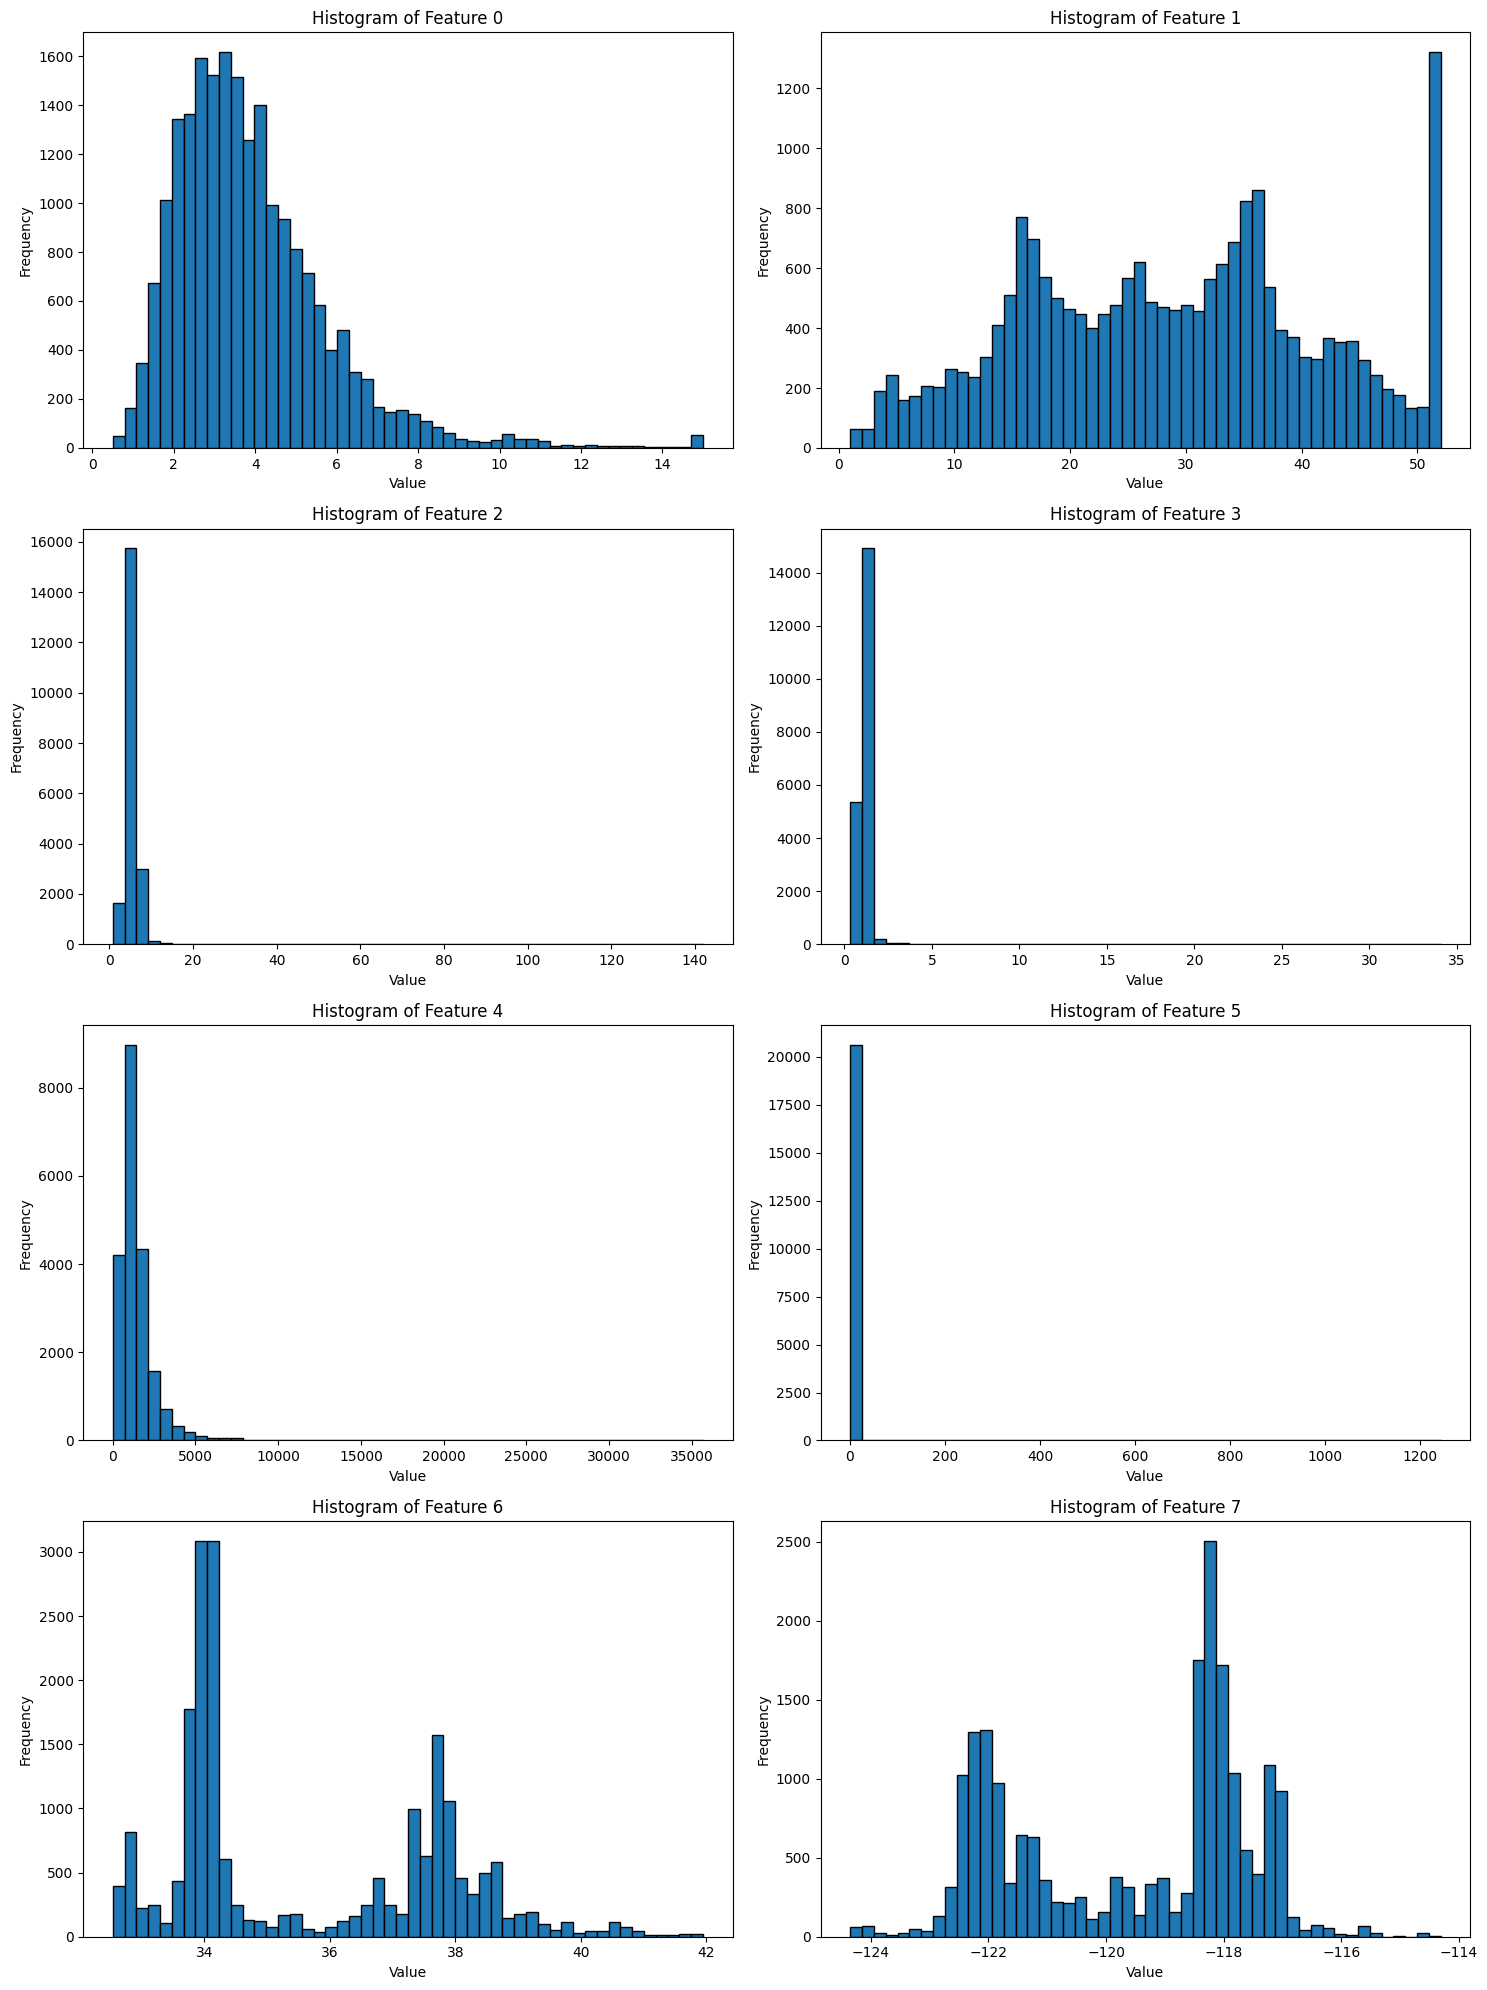

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert X to a Pandas DataFrame for easier plotting with column names if available
# If column names are not known, default integer indices will be used.
X_df = pd.DataFrame(X)

# Get the number of features
num_features = X_df.shape[1]

# Determine grid size for subplots
rows = (num_features + 1) // 2  # At least 1 row, 2 columns
cols = 2

plt.figure(figsize=(15, 5 * rows))

for i in range(num_features):
    plt.subplot(rows, cols, i + 1) # Create subplot for each feature
    plt.hist(X_df.iloc[:, i], bins=50, edgecolor='black')
    plt.title(f'Histogram of Feature {i}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [6]:
# The question 'do we need to consider all the features' implies a need for feature analysis.
# A common next step is to examine correlations.
# I will propose generating a correlation matrix in my response.

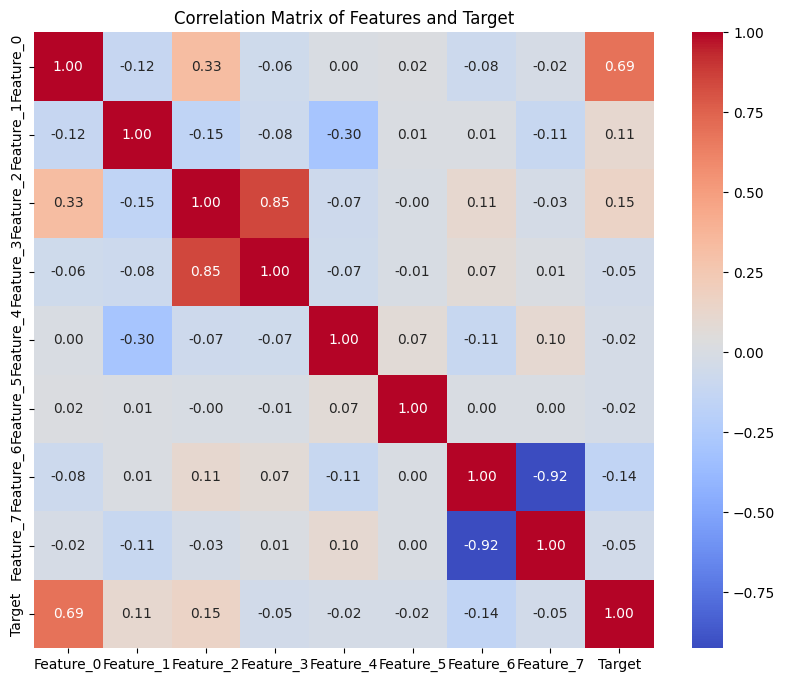


Correlations with the Target variable:
Target       1.000000
Feature_0    0.688075
Feature_2    0.151948
Feature_1    0.105623
Feature_5   -0.023737
Feature_4   -0.024650
Feature_7   -0.045967
Feature_3   -0.046701
Feature_6   -0.144160
Name: Target, dtype: float64


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Combine features (X) and target (y) into a single DataFrame for correlation analysis
# If column names are available, it's good practice to use them, otherwise use generic names.
feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
df_combined = pd.DataFrame(X, columns=feature_names)
df_combined['Target'] = y

# Calculate the correlation matrix
correlation_matrix = df_combined.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Target')
plt.show()

print("\nCorrelations with the Target variable:")
print(correlation_matrix['Target'].sort_values(ascending=False))